In [38]:
from pathlib import Path
import sys

current_dir = Path.cwd()

if (current_dir / "src").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "src").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not locate project root containing 'src'."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: e:\github\BTC-and-ETH-Data-Analyst-and-Prediction


In [39]:
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from src.preprocessing import (
    clean_market_data,
    temporal_split
)

from src.feature_engineering import (
    add_technical_indicators,
)

from src.model import build_lstm_model

In [40]:
FEATURE_COLUMNS = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "SMA_10",
    "SMA_30",
    "EMA_5",
    "EMA_20",
    "RSI_14",
    "MACD",
    "MACD_Signal"
]

TARGET_COLUMNS = [
    "Open",
    "High",
    "Low",
    "Close"
]

ASSET = "ETH-USD"

In [41]:
data_path = (
    PROJECT_ROOT
    / "data"
    / "sample"
    / "test_crypto_data.csv"
)

In [60]:
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {data_path}"
    )

df = pd.read_csv(data_path)

df = clean_market_data(df)
df = add_technical_indicators(df)

asset_df = (
    df[df["Asset"] == ASSET]
    .sort_values("Date")
    .reset_index(drop=True)
)

if asset_df.empty:
    raise ValueError(
        f"No data found for {ASSET}. "
        f"Available assets: {df['Asset'].unique().tolist()}"
    )

print("Selected asset:", ASSET)
print("Available observations:", len(asset_df))

asset_df.head()

Selected asset: ETH-USD
Available observations: 2945


,Date,Asset,Open,High,Low,Close,Volume,SMA_10,SMA_30,EMA_5,EMA_20,RSI_14,MACD,MACD_Signal
0,2017-12-08,ETH-USD,434.989014,466.062012,422.367004,456.031006,2336379904,452.299106,400.082003,449.391986,431.286059,45.120639,25.885959,30.573899
1,2017-12-09,ETH-USD,457.343994,504.147003,456.252991,473.502014,2003849984,456.897006,405.169270,457.428662,435.306626,51.785929,26.163721,29.691864
2,2017-12-10,ETH-USD,472.789001,472.789001,429.514008,441.721008,1404179968,456.357706,409.918204,452.192778,435.917520,43.536034,23.547942,28.463079
3,2017-12-11,ETH-USD,440.358002,516.968994,439.104004,515.135986,1771440000,461.217303,416.600037,473.173847,443.462135,55.926804,27.086656,28.187795
4,2017-12-12,ETH-USD,522.286011,657.317993,504.493988,651.431030,5179829760,480.015506,428.050805,532.592908,463.268697,71.139552,40.423011,30.634838


In [61]:
train_df, validation_df, test_df = temporal_split(
    asset_df,
    train_ratio=0.80,
    validation_ratio=0.10
)

print("Training rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Test rows:", len(test_df))

Training rows: 2356
Validation rows: 294
Test rows: 295


In [44]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

feature_scaler.fit(
    train_df[FEATURE_COLUMNS]
)

target_scaler.fit(
    train_df[TARGET_COLUMNS]
)

train_features = feature_scaler.transform(
    train_df[FEATURE_COLUMNS]
)

train_targets = target_scaler.transform(
    train_df[TARGET_COLUMNS]
)

validation_features = feature_scaler.transform(
    validation_df[FEATURE_COLUMNS]
)

validation_targets = target_scaler.transform(
    validation_df[TARGET_COLUMNS]
)

In [ ]:
BASELINE_CONFIG = {
    "time_steps": 10,
    "units": 128,
    "learning_rate": 0.0005,
    "batch_size": 32,
    "max_epochs": 100,
}

max_epochs = 100
patience = 10

In [46]:
PARAMETER_GRID = {
    "time_steps": [10, 30, 60],
    "units": [32, 64, 128, 256],
    "learning_rate": [0.001, 0.0005, 0.0001],
    "batch_size": [16, 32, 64, 128]
}

In [47]:
train_features
train_targets
validation_features
validation_targets
import numpy as np
import tensorflow as tf

from keras.callbacks import EarlyStopping
from keras import backend as K

from src.feature_engineering import create_sequences
from src.utils import set_random_seed


def run_experiment(
    train_features,
    train_targets,
    validation_features,
    validation_targets,
    time_steps=10,
    units=128,
    learning_rate=0.0005,
    batch_size=32,
    max_epochs=100
):
    """Train one LSTM configuration and return validation results."""

    # Create training sequences.
    x_train, y_train = create_sequences(
        train_features,
        train_targets,
        time_steps=time_steps
    )

    # Add the last training observations to the validation context.
    validation_features_with_context = np.concatenate(
        [
            train_features[-time_steps:],
            validation_features
        ],
        axis=0
    )

    validation_targets_with_context = np.concatenate(
        [
            train_targets[-time_steps:],
            validation_targets
        ],
        axis=0
    )

    x_validation, y_validation = create_sequences(
        validation_features_with_context,
        validation_targets_with_context,
        time_steps=time_steps
    )

    # Clear the previous model before starting another experiment.
    K.clear_session()
    set_random_seed(42)

    model = build_lstm_model(
        input_shape=(
            x_train.shape[1],
            x_train.shape[2]
        ),
        units=units,
        output_size=y_train.shape[1],
        learning_rate=learning_rate
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(
            x_validation,
            y_validation
        ),
        epochs=max_epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=[early_stopping],
        verbose=0
    )

    return {
        "time_steps": time_steps,
        "units": units,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "epochs_completed": len(history.history["loss"]),
        "best_training_loss": min(history.history["loss"]),
        "best_validation_loss": min(history.history["val_loss"])
    }

In [ ]:
time_step_results = []

for time_steps in [10, 30, 60]:
    result = run_experiment(
        train_features=train_features,
        train_targets=train_targets,
        validation_features=validation_features,
        validation_targets=validation_targets,
        time_steps=time_steps,
        units=128,
        learning_rate=0.0005,
        batch_size=32
    )

    time_step_results.append(result)

time_step_results_df = pd.DataFrame(time_step_results)

time_step_results_df.sort_values(
    "best_validation_loss"
)

,time_steps,units,learning_rate,batch_size,epochs_completed,best_training_loss,best_validation_loss
1,30,128,0.0005,32,75,0.000590,0.000549
0,10,128,0.0005,32,74,0.000612,0.000603
2,60,128,0.0005,32,53,0.000800,0.000743


In [ ]:
unit_results = []

for units in [32, 64, 128, 256]:
    result = run_experiment(
        train_features=train_features,
        train_targets=train_targets,
        validation_features=validation_features,
        validation_targets=validation_targets,
        time_steps=10,
        units=units,
        learning_rate=0.0005,
        batch_size=32
    )

    unit_results.append(result)

unit_results_df = pd.DataFrame(unit_results)

unit_results_df.sort_values(
    "best_validation_loss"
)

,time_steps,units,learning_rate,batch_size,epochs_completed,best_training_loss,best_validation_loss
3,10,256,0.0005,32,57,0.000601,0.000602
2,10,128,0.0005,32,74,0.000612,0.000603
1,10,64,0.0005,32,68,0.000793,0.000907
0,10,32,0.0005,32,34,0.001379,0.001830


In [ ]:
learning_rate_results = []

for learning_rate in [0.001, 0.0005, 0.0001]:
    result = run_experiment(
        train_features=train_features,
        train_targets=train_targets,
        validation_features=validation_features,
        validation_targets=validation_targets,
        time_steps=10,
        units=128,
        learning_rate=learning_rate,
        batch_size=32
    )

    learning_rate_results.append(result)

learning_rate_results_df = pd.DataFrame(
    learning_rate_results
)

learning_rate_results_df.sort_values(
    "best_validation_loss"
)

,time_steps,units,learning_rate,batch_size,epochs_completed,best_training_loss,best_validation_loss
1,10,128,0.0005,32,74,0.000612,0.000603
0,10,128,0.0010,32,55,0.000771,0.000650
2,10,128,0.0001,32,100,0.000800,0.001054


In [ ]:
batch_size_results = []

for batch_size in [16, 32, 64, 128]:
    result = run_experiment(
        train_features=train_features,
        train_targets=train_targets,
        validation_features=validation_features,
        validation_targets=validation_targets,
        time_steps=10,
        units=128,
        learning_rate=0.0005,
        batch_size=batch_size
    )

    batch_size_results.append(result)

batch_size_results_df = pd.DataFrame(
    batch_size_results
)

batch_size_results_df.sort_values(
    "best_validation_loss"
)

,time_steps,units,learning_rate,batch_size,epochs_completed,best_training_loss,best_validation_loss
1,10,128,0.0005,32,74,0.000612,0.000603
0,10,128,0.0005,16,44,0.000913,0.000893
3,10,128,0.0005,128,56,0.001504,0.001530
2,10,128,0.0005,64,14,0.002823,0.005060


In [ ]:
all_results = pd.concat(
    [
        time_step_results_df,
        unit_results_df,
        learning_rate_results_df,
        batch_size_results_df
    ],
    ignore_index=True
)

all_results.to_csv(
    PROJECT_ROOT /
    "results/hyperparameter_results.csv",
    index=False
)

all_results

,time_steps,units,learning_rate,batch_size,epochs_completed,best_training_loss,best_validation_loss
0,10,128,0.0005,32,74,0.000612,0.000603
1,30,128,0.0005,32,75,0.000590,0.000549
2,60,128,0.0005,32,53,0.000800,0.000743
3,10,32,0.0005,32,34,0.001379,0.001830
4,10,64,0.0005,32,68,0.000793,0.000907
5,10,128,0.0005,32,74,0.000612,0.000603
6,10,256,0.0005,32,57,0.000601,0.000602
7,10,128,0.0010,32,55,0.000771,0.000650
8,10,128,0.0005,32,74,0.000612,0.000603
9,10,128,0.0001,32,100,0.000800,0.001054


In [58]:
import matplotlib.pyplot as plt


def plot_parameter_results(
    results_df,
    parameter,
    title
):
    summary = (
        results_df
        .groupby(parameter, as_index=False)
        ["best_validation_loss"]
        .min()
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        summary[parameter],
        summary["best_validation_loss"],
        marker="o"
    )

    plt.title(title)
    plt.xlabel(parameter)
    plt.ylabel("Best Validation Loss")
    plt.grid(alpha=0.3)
    plt.show()

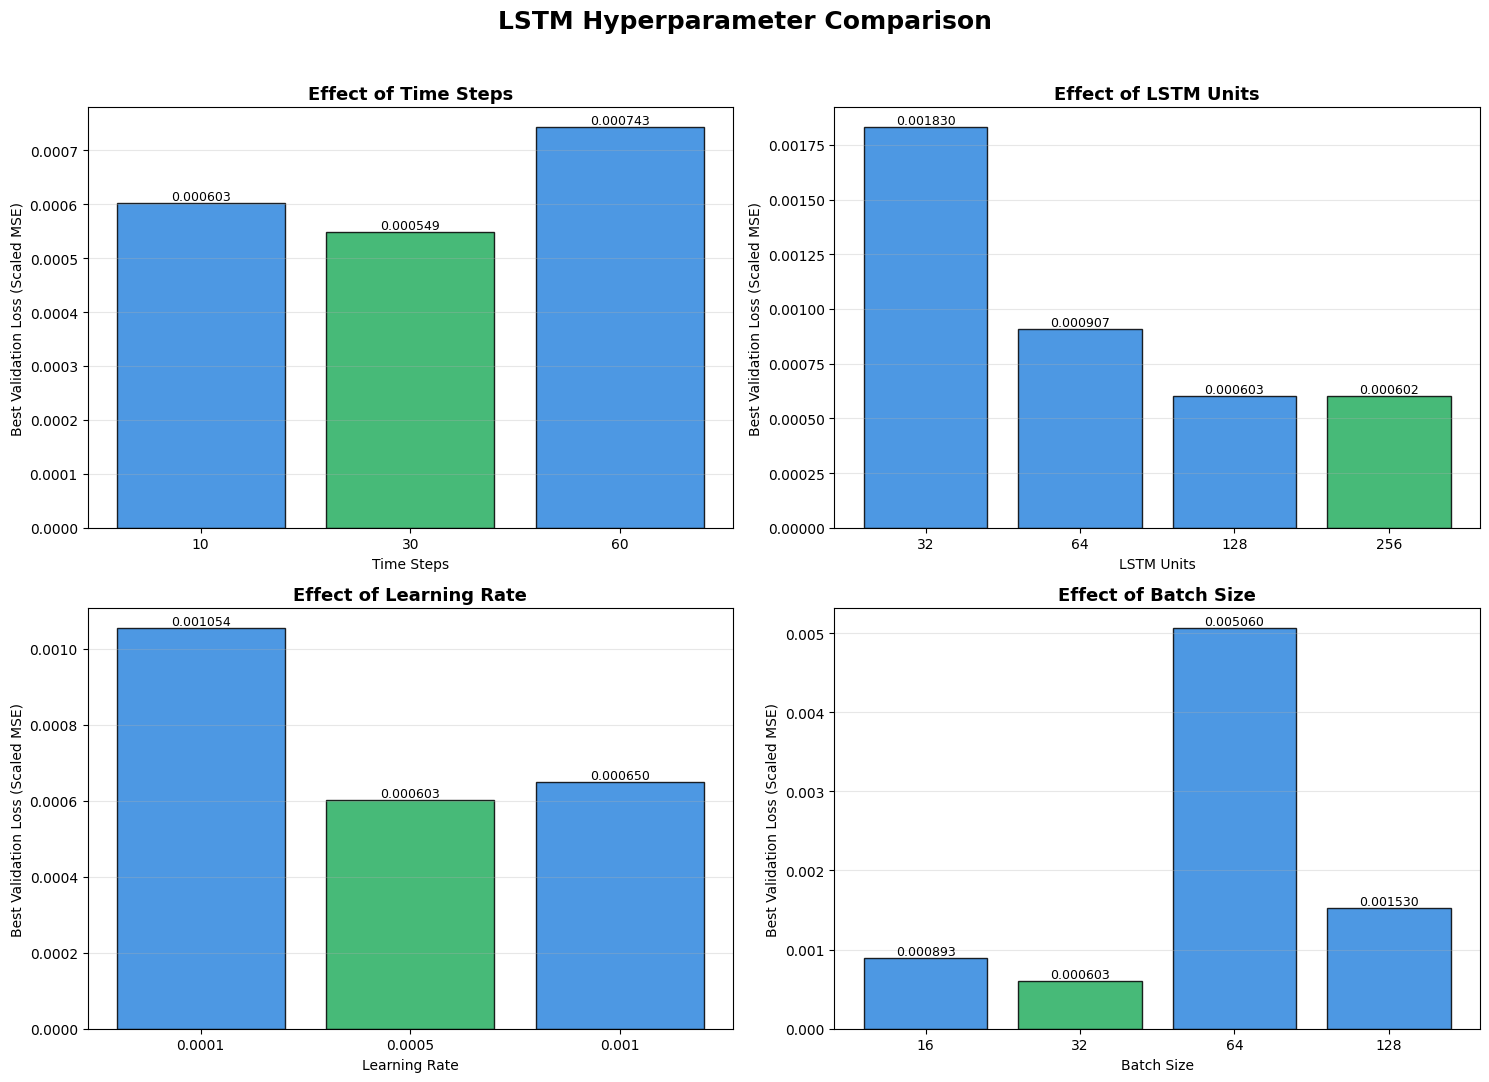

Figure saved to: e:\github\BTC-and-ETH-Data-Analyst-and-Prediction\results\figures\hyperparameter_comparison.png


In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Epoch comparison has been removed
parameter_results = {
    "Time Steps": (
        time_step_results,
        "time_steps"
    ),
    "LSTM Units": (
        unit_results,
        "units"
    ),
    "Learning Rate": (
        learning_rate_results,
        "learning_rate"
    ),
    "Batch Size": (
        batch_size_results,
        "batch_size"
    ),
}

# Four parameters use a 2 × 2 layout
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 11)
)

axes = axes.flatten()

for ax, (
    parameter_name,
    (results_data, value_column)
) in zip(
    axes,
    parameter_results.items()
):
    # Convert list into DataFrame
    results_df = pd.DataFrame(results_data)

    if results_df.empty:
        ax.set_title(
            f"{parameter_name}: No results"
        )
        ax.axis("off")
        continue

    required_columns = [
        value_column,
        "best_validation_loss"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in results_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{parameter_name} results are missing: "
            f"{missing_columns}. Available columns: "
            f"{results_df.columns.tolist()}"
        )

    plot_df = (
        results_df
        .sort_values(value_column)
        .reset_index(drop=True)
    )

    x_positions = np.arange(len(plot_df))

    losses = (
        plot_df["best_validation_loss"]
        .astype(float)
        .to_numpy()
    )

    labels = (
        plot_df[value_column]
        .astype(str)
        .tolist()
    )

    # Find the lowest validation loss
    best_position = int(np.argmin(losses))

    # Highlight the best result in green
    colors = [
        "#27AE60"
        if index == best_position
        else "#2E86DE"
        for index in range(len(plot_df))
    ]

    bars = ax.bar(
        x_positions,
        losses,
        color=colors,
        edgecolor="black",
        alpha=0.85
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)

    ax.set_title(
        f"Effect of {parameter_name}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(parameter_name)
    ax.set_ylabel(
        "Best Validation Loss (Scaled MSE)"
    )

    ax.grid(
        axis="y",
        alpha=0.3
    )

    # Display values above the bars
    for bar, loss in zip(bars, losses):
        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
            f"{loss:.6f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

fig.suptitle(
    "LSTM Hyperparameter Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

output_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "hyperparameter_comparison.png"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", output_path)

In [53]:
import pandas as pd

best_parameter_rows = []

for parameter_name, (
    results_data,
    value_column
) in parameter_results.items():

    # Convert list into DataFrame
    results_df = pd.DataFrame(results_data)

    if results_df.empty:
        print(
            f"Warning: No results for "
            f"{parameter_name}"
        )
        continue

    if "best_validation_loss" not in results_df.columns:
        raise ValueError(
            f"{parameter_name} does not contain "
            "'best_validation_loss'. "
            f"Available columns: "
            f"{results_df.columns.tolist()}"
        )

    if value_column not in results_df.columns:
        raise ValueError(
            f"{parameter_name} does not contain "
            f"'{value_column}'. "
            f"Available columns: "
            f"{results_df.columns.tolist()}"
        )

    # Find the row with the lowest validation loss
    best_index = (
        results_df["best_validation_loss"]
        .astype(float)
        .idxmin()
    )

    best_row = results_df.loc[best_index]

    best_parameter_rows.append({
        "Parameter": parameter_name,

        "Best_Value":
            best_row[value_column],

        "Best_Validation_Loss":
            best_row["best_validation_loss"],

        "Best_Training_Loss":
            best_row["best_training_loss"],

        "Epochs_Completed":
            best_row["epochs_completed"]
    })


best_parameters_df = pd.DataFrame(
    best_parameter_rows
)

display(best_parameters_df)

,Parameter,Best_Value,Best_Validation_Loss,Best_Training_Loss,Epochs_Completed
0,Time Steps,30.0000,0.000549,0.000590,75.0
1,LSTM Units,256.0000,0.000602,0.000601,57.0
2,Learning Rate,0.0005,0.000603,0.000612,74.0
3,Batch Size,32.0000,0.000603,0.000612,74.0


In [54]:
summary_path = (
    PROJECT_ROOT
    / "results"
    / "best_hyperparameters.csv"
)

best_parameters_df.to_csv(
    summary_path,
    index=False
)

print("Summary saved to:", summary_path)

Summary saved to: e:\github\BTC-and-ETH-Data-Analyst-and-Prediction\results\best_hyperparameters.csv


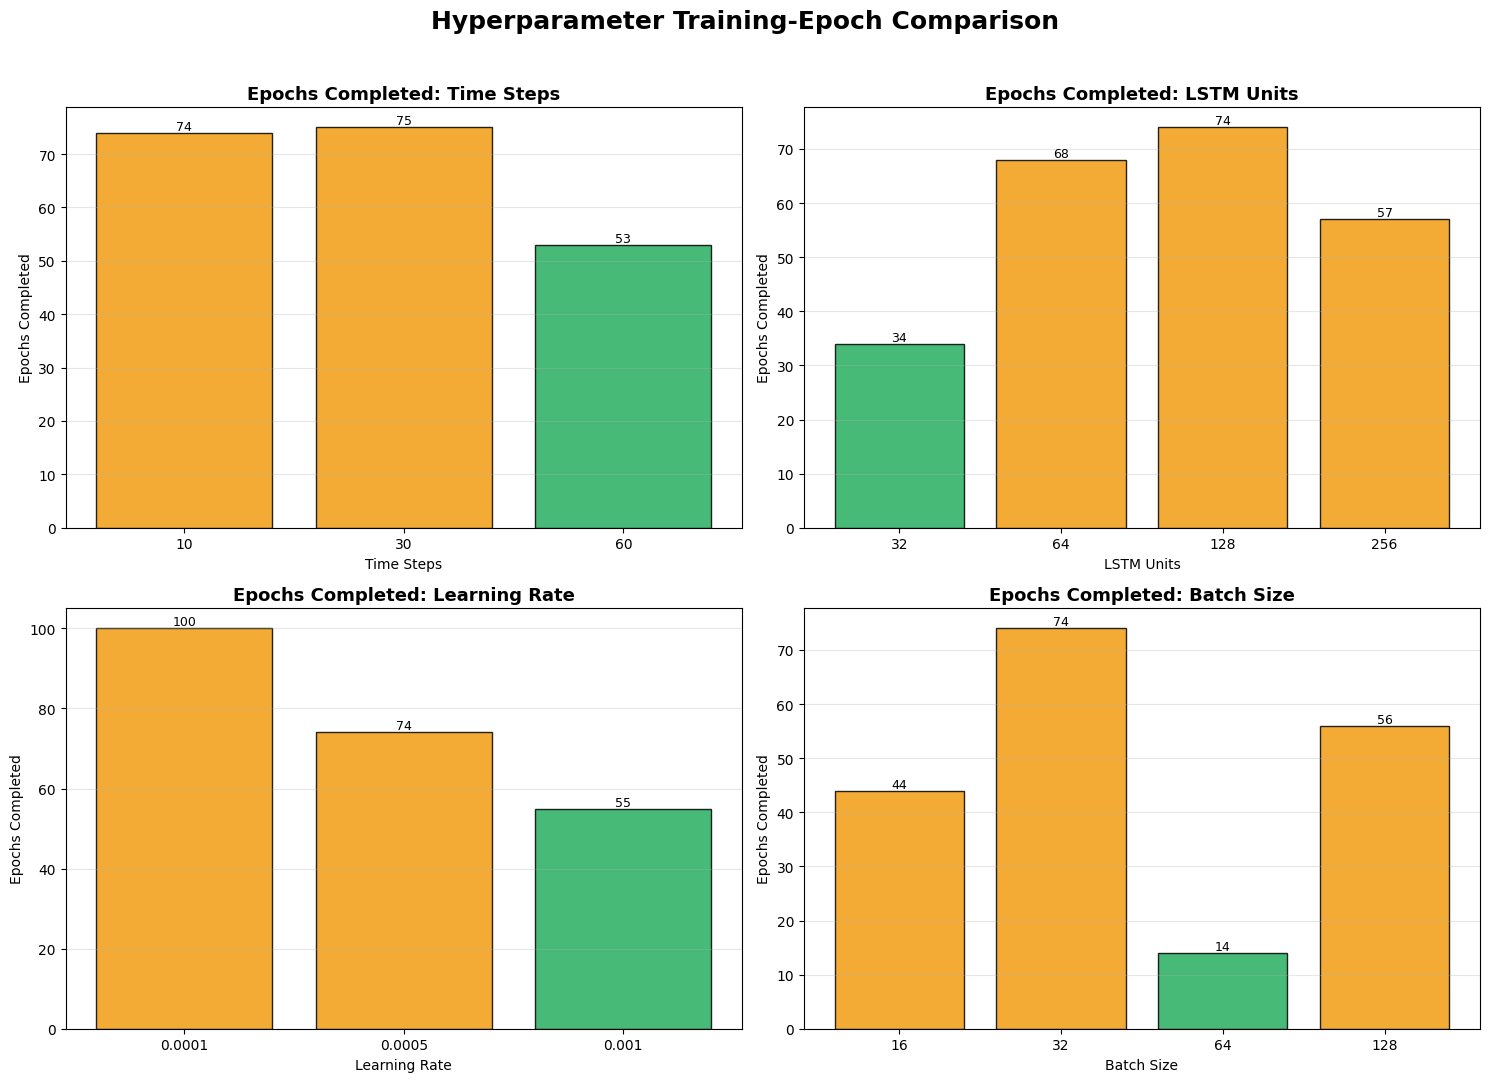

Figure saved to: e:\github\BTC-and-ETH-Data-Analyst-and-Prediction\results\figures\hyperparameter_epochs_completed.png


In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Four parameters: use a 2 × 2 layout
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 11)
)

axes = axes.flatten()

for ax, (
    parameter_name,
    (results_data, value_column)
) in zip(
    axes,
    parameter_results.items()
):
    results_df = pd.DataFrame(
        results_data
    )

    if results_df.empty:
        ax.set_title(
            f"{parameter_name}: No results"
        )
        ax.axis("off")
        continue

    required_columns = [
        value_column,
        "epochs_completed"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in results_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{parameter_name} results are missing: "
            f"{missing_columns}. Available columns: "
            f"{results_df.columns.tolist()}"
        )

    plot_df = (
        results_df
        .sort_values(value_column)
        .reset_index(drop=True)
    )

    x_positions = np.arange(
        len(plot_df)
    )

    epochs_completed = (
        plot_df["epochs_completed"]
        .astype(int)
        .to_numpy()
    )

    labels = (
        plot_df[value_column]
        .astype(str)
        .tolist()
    )

    # Highlight the configuration that
    # completed the fewest epochs
    minimum_position = int(
        np.argmin(epochs_completed)
    )

    colors = [
        "#27AE60"
        if index == minimum_position
        else "#F39C12"
        for index in range(len(plot_df))
    ]

    bars = ax.bar(
        x_positions,
        epochs_completed,
        color=colors,
        edgecolor="black",
        alpha=0.85
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)

    ax.set_title(
        f"Epochs Completed: {parameter_name}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(parameter_name)
    ax.set_ylabel("Epochs Completed")

    ax.grid(
        axis="y",
        alpha=0.3
    )

    for bar, epochs in zip(
        bars,
        epochs_completed
    ):
        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
            f"{epochs}",
            ha="center",
            va="bottom",
            fontsize=9
        )

fig.suptitle(
    "Hyperparameter Training-Epoch Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

epoch_figure_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "hyperparameter_epochs_completed.png"
)

epoch_figure_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    epoch_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved to:",
    epoch_figure_path
)